In [1]:
import os
os.sys.path.append('/data/scratch/globc/bonassies/workspace/swot_for_flood')
import geopandas as gpd
import configparser
from pathlib import Path
from matplotlib import pyplot as plt
import seaborn as sns
from cmap import Colormap

from core.swot_project import SwotProject
from core.plot_raster import PlotRaster

main_path = "/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/EMSR_692"

# Plotting for EMSR 692

This notebook uses the rasters generated by EMSR692_pretreat.ipynb to plot the results of the EMSR 692 exercise. The rasters are stored in the `rasters` folder and the plots are stored in the `plots` folder.

First, we need to load the project:

In [2]:
config = configparser.ConfigParser()
config.read(main_path + '/config.cfg')

# print(type(config),dict(config['CONFIG']))

['/data/scratch/globc/bonassies/workspace/swot_for_flood/examples/EMSR_692/config.cfg']

In [3]:
swot_project = SwotProject(config)
# print(swot_project)

No automatic download, please use the Downloader object to download the data


In [4]:
swot_project.find_raster()


Then, once loaded, we need to create, load and pre-treat the SWOT data used for plotting.
Here we use the collection object within the project to create a new collection with the dry and flooded times selected.

In [5]:
# takes around 2 minutes for 5 raster files of 1.65Go
swot_project.create_collection()

Opening SWOT raster at time: 2023-09-15 07:08:16
Opening SWOT raster at time: 2023-09-15 20:23:11
Opening SWOT raster at time: 2024-05-01 19:24:06
Opening SWOT raster at time: 2024-04-11 11:53:58
Opening SWOT raster at time: 2024-04-10 22:39:02


We can then create the plot object that we will use to plot the data.

In [6]:
plot_obj = PlotRaster(
    swot_project,
    save_fig=True,
    show_fig=True
    )

Finally, we can plot the data using the plot object.

Below, a function to plot the control area and histograms associated with the control area.

(<Figure size 1500x500 with 4 Axes>,
 array([<Axes: title={'center': '$\\gamma_{total}$ - Mean data'}, ylabel='Farkadona, Greece - EMSR 692'>,
        <Axes: title={'center': '$\\gamma_{total}$ - 2023-09-15 07:08'}>,
        <Axes: xlabel='$\\gamma_{total}$'>], dtype=object))

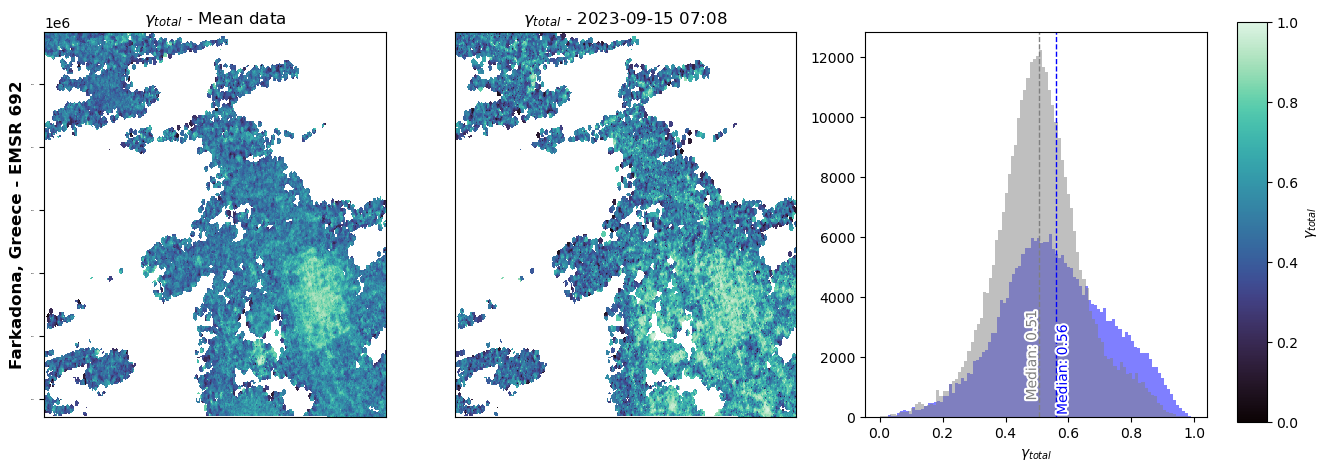

In [7]:
plot_obj.plot_control_maps_and_histograms(
    'gamma_tot', 
    time_selection="2023-09-15 07:08:16",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    y_label="Farkadona, Greece - EMSR 692",
    vmin=0,
    vmax=1,
    )


Plot mean histograms with the dates that compose the mean.

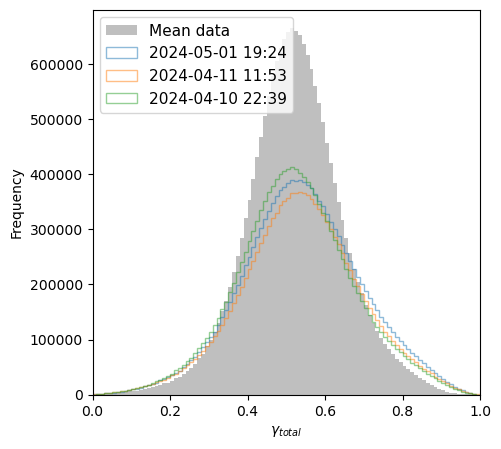

In [ ]:
fig,ax = plot_obj.plot_mean_hist_computation(
    'gamma_tot',
    hist_range=(0,1),
    add_legend=False
)

Below, the function to plot a map.

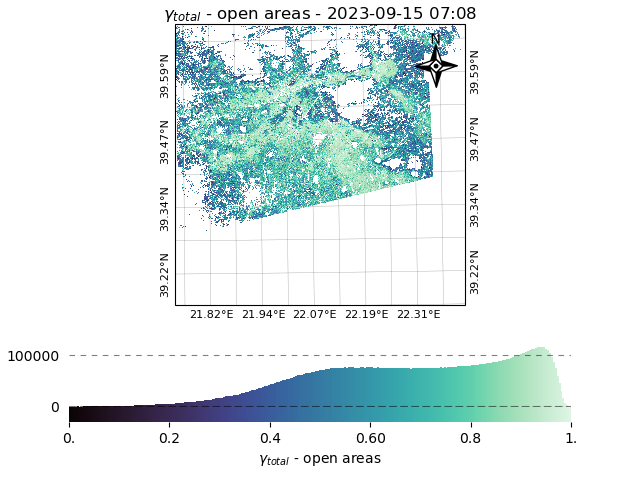

In [7]:
# takes around 1 minute
fig, ax = plot_obj.plot_map(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection='open',
    time_selection="2023-09-15 07:08:16",
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    vmin=0,
    vmax=1,
    add_bkg=False
    )

Below a function to plot an histogram.

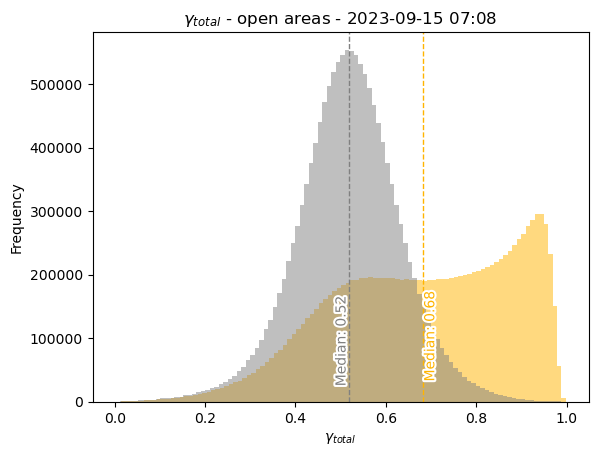

In [10]:
# takes around 1 minute for seaborn method, 15s for matplotlib method
fig, ax = plot_obj.plot_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    world_cover_selection='open',
    time_selection="2023-09-15 07:08:16",
    use_seaborn=False
    )

And then, the function to combine maps and histograms.

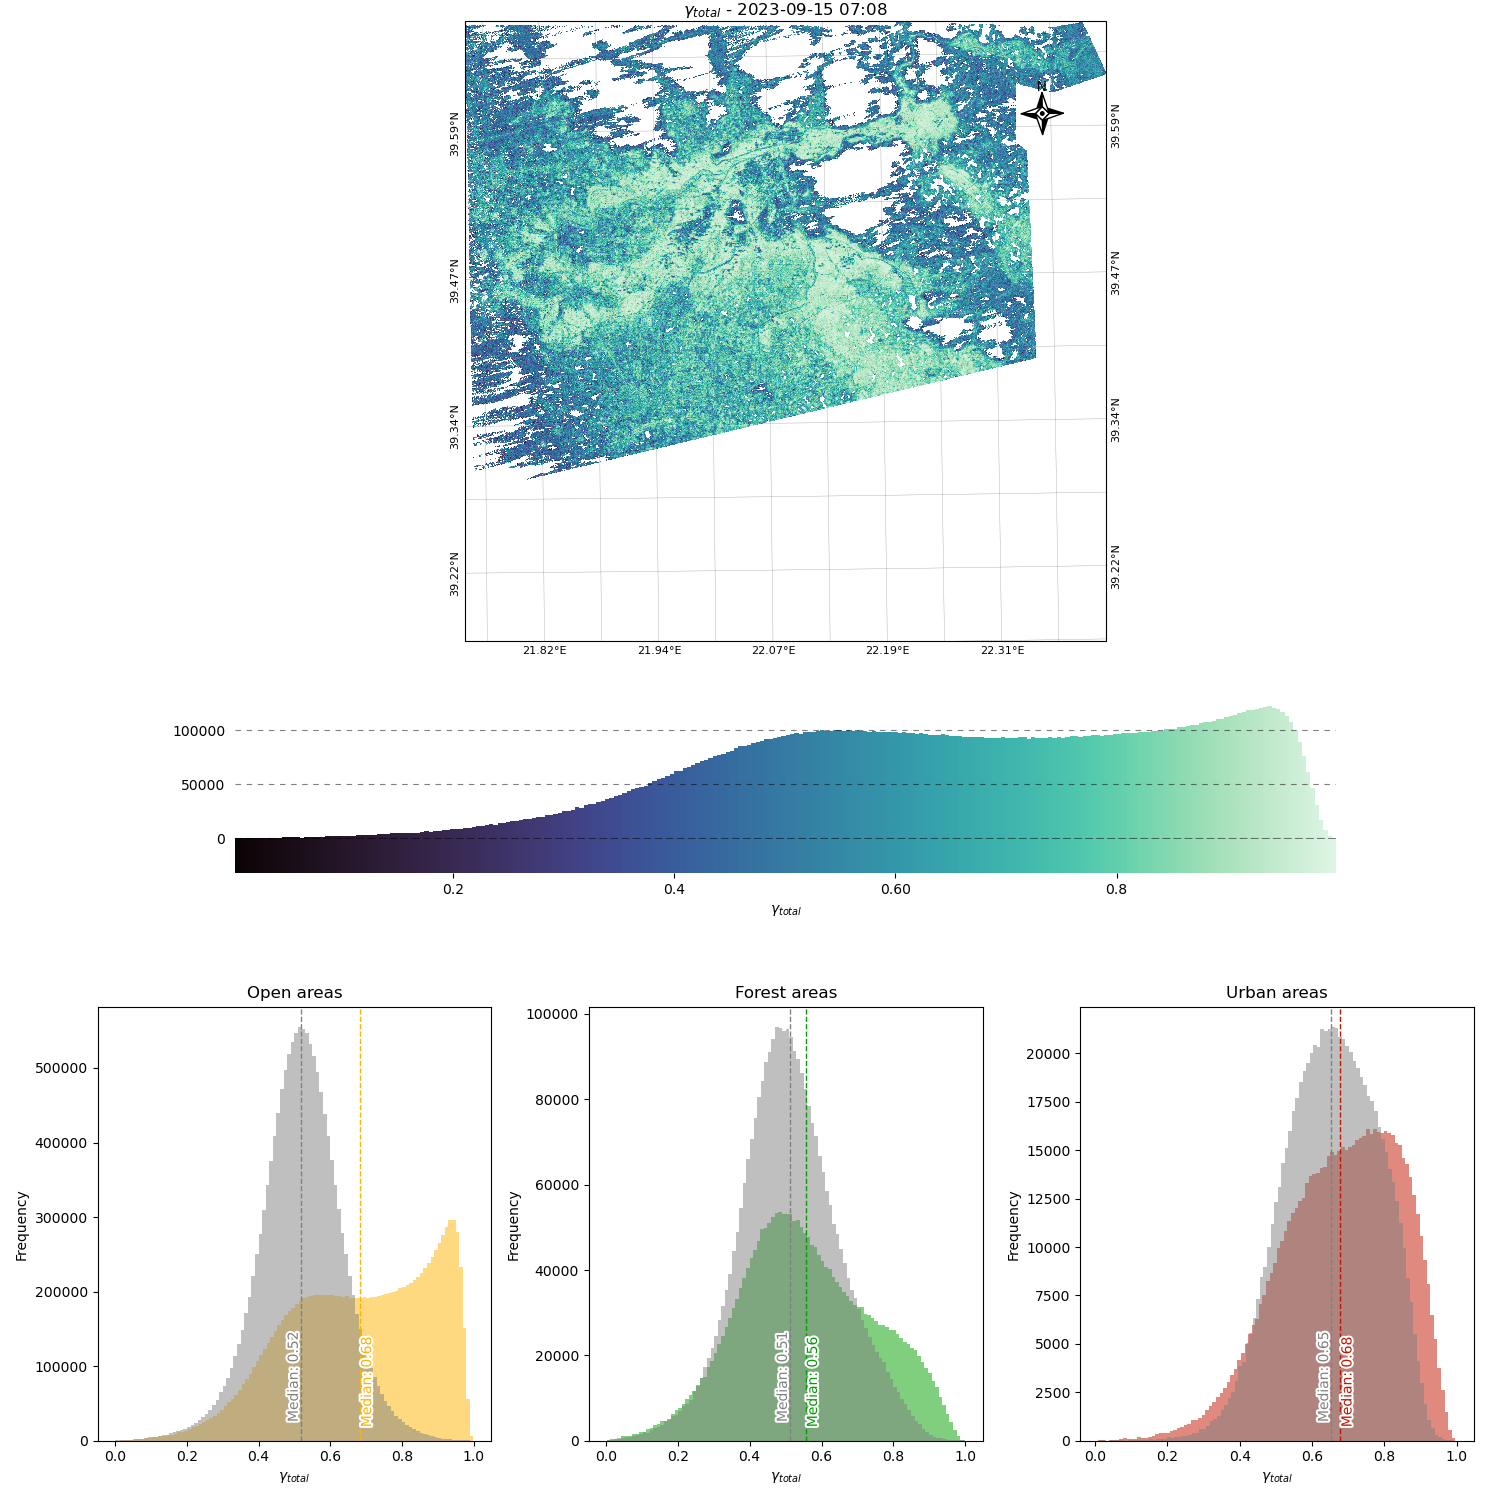

In [14]:
# takes around 1 minute 15s for matplotlib method, 4 minutes for seaborn method
fig, ax = plot_obj.plot_map_with_histogram(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2023-09-15 07:08:16",
    add_bkg=False,
    cmap=Colormap("seaborn:mako").to_matplotlib(),
    use_seaborn=False
    )

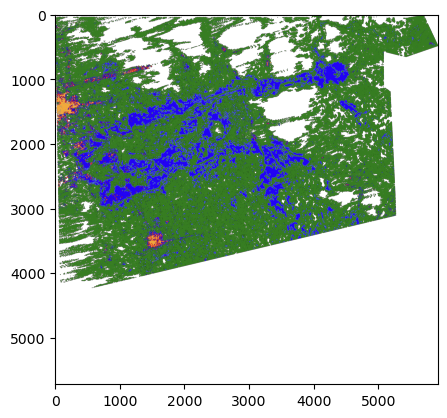

In [10]:
from auxiliary.cbar_SWOT import *
cmap_SWOT, normalizer_SWOT, boundaries_SWOT, ticks_SWOT, tick_labels_SWOT, values_SWOT = defined_SWOT_cmap()
classif = plot_obj.swot_collection.get_variable("classification", "global", "swot", None)
plt.imshow(classif.data[0], cmap=cmap_SWOT, norm=normalizer_SWOT)
plt.show()

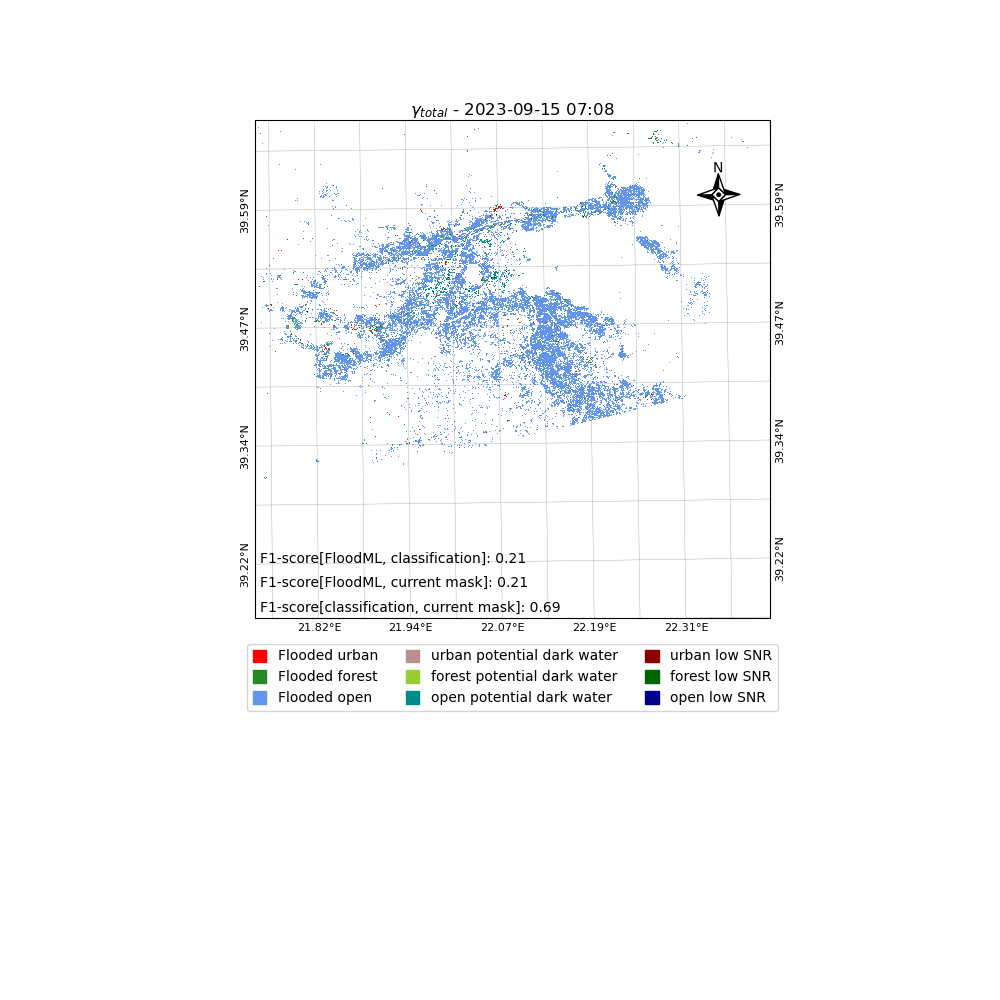

In [7]:
# takes around 5 minutes
fig, ax = plot_obj.plot_map_mask(
    variable="gamma_tot",
    data_area="global",
    data_type="swot",
    time_selection="2023-09-15 07:08:16",
    comparing_raster_Path=plot_obj.project.AUX_PATH.joinpath("FM_34SEJ_20230915_CUT_nrow5720_ncol5917.tif"),
    thresholds={"urban":0.9, "forest":0.85, "open":0.85},
    add_classif_score=True,
    add_uncertainty=True,
    threshold_SNR=0.5,
    add_bkg=False,
    add_legend=True,
    )